# Задача 7. Нейронные сети

## Задача

- [ ] Найти данные в виде изображений для задачи классификации. Например, можно взять данные [отсюда](http://ufldl.stanford.edu/housenumbers/).
- [ ] Реализовать классы, необходимые для построения сети со следующими слоями
	- FullyConnectedLayer
	- ReluLayer
	- FullyConnectedLayer
- [ ] Использовать CrossEntropyLoss и L2-регуляризацию.
- [ ] Обучить модель на тренировочных данных, подбирать параметры (особенно learning rate) на валидационной и оценить качество на тестовой. Анализировать графики train/val loss, проверять на каждом шаге корректность вычисления градиентов с помощью разностной оценки.
- [ ] * (**+2 балла**) Добавить Batch normalization.
- [ ] * (**+2 балла**) В качестве оптимизатор использовать один из: Momentum, RMSprop.
- [ ] * (**+1 балл**) Также реализовать оптимизатор Adam.

## Импорты

In [93]:
import torch

import matplotlib.pyplot as plt
import torch.nn as nn

from random import sample
from torch.utils.data import random_split, DataLoader
from torchvision import transforms, datasets
from collections import defaultdict

In [94]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Датасет
В качестве датасета для задачи многоклассовой классификации был выбран Fashion-MNIST — современный аналог классического MNIST, содержащий изображения предметов одежды. Он состоит из 70 000 изображений размером 28×28 пикселей, распределённых по 10 классам, включая такие категории как "футболка", "кроссовки", "пальто", "сумка" и другие.

In [95]:
fashion_transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.2860,), (0.3530,))]
)

In [96]:
fashion_train_dataset = torchvision.datasets.FashionMNIST(
    root='./fashion-mnist',
    train=True,
    download=True,
    transform=fashion_transform
)

fashion_test_dataset = torchvision.datasets.FashionMNIST(
    root='./fashion-mnist',
    train=False,
    download=True,
    transform=fashion_transform
)


Визуализируем данные.

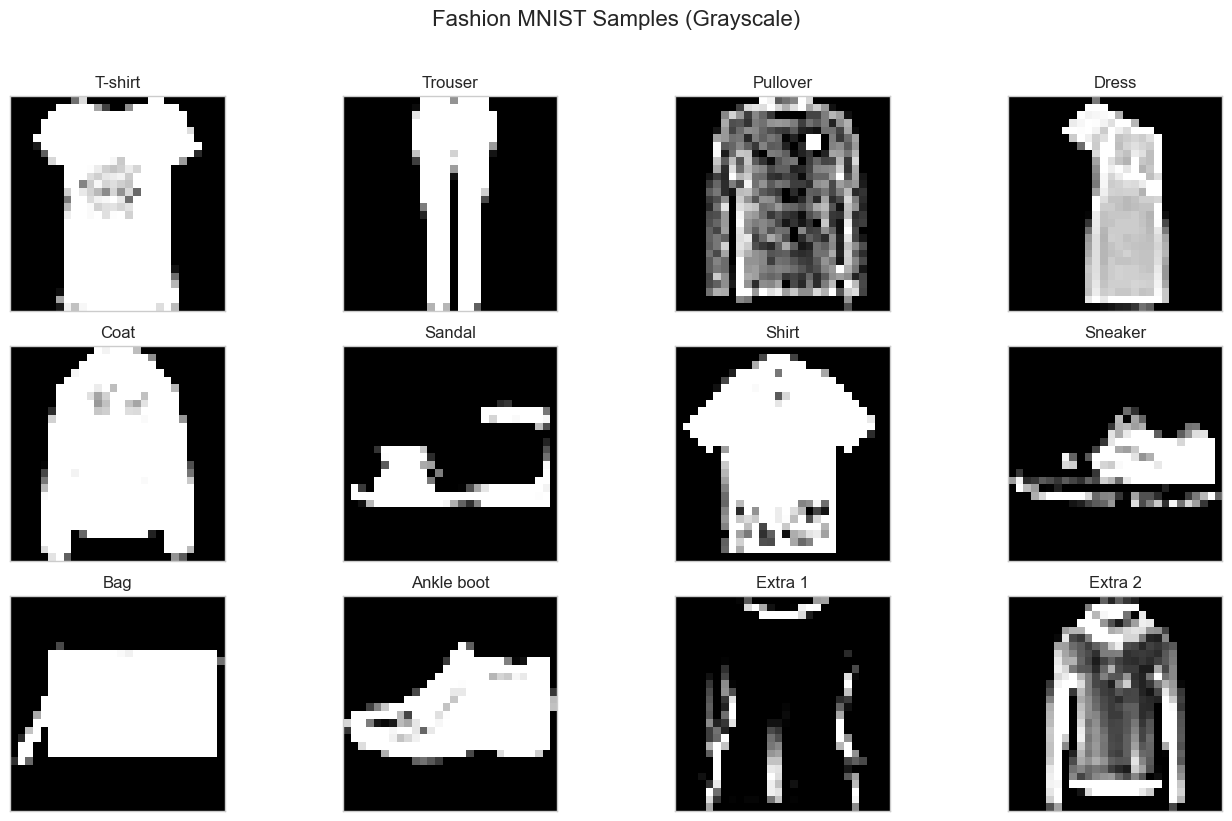

In [97]:
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(14, 8), facecolor='white')
fig.suptitle('Fashion MNIST Samples (Grayscale)', fontsize=16, y=1.02)

class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

selected_indices = []
class_indices = defaultdict(list)

for idx in range(len(fashion_train_dataset)):
    _, label = fashion_train_dataset[idx]
    class_indices[label].append(idx)

for label in sorted(class_indices.keys()):
    selected_indices.append(sample(class_indices[label], 1)[0])

remaining_indices = [i for i in range(len(fashion_train_dataset)) if i not in selected_indices]
selected_indices.extend(sample(remaining_indices, 2))

for idx, img_idx in enumerate(selected_indices):
    ax = fig.add_subplot(3, 4, idx+1)
    image, label = fashion_train_dataset[img_idx]
    
    ax.imshow(image.squeeze(), cmap='gray', vmin=0, vmax=1)
    ax.set_title(class_names[label] if idx < 10 else f'Extra {idx-9}')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)

plt.tight_layout()
plt.show()

In [98]:
val_size = int(len(fashion_train_dataset) * 0.1)
train_size = len(fashion_train_dataset) - val_size

train_subset, val_subset = random_split(
    fashion_train_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Train data: {len(train_subset)}")
print(f"Validation data: {len(val_subset)}")

Train data: 54000
Validation data: 6000


In [99]:
batch_size = 64

train_loader = DataLoader(
    train_subset, 
    batch_size=batch_size, 
    shuffle=True, 
    num_workers=2
)
val_loader = DataLoader(
    val_subset, 
    batch_size=batch_size, 
    shuffle=False, 
    num_workers=2
)

test_loader = DataLoader(
    fashion_test_dataset, 
    batch_size=batch_size, 
    shuffle=False, 
    num_workers=2
)

print(f"Batch size: {batch_size}")
print(f"Train: {len(train_loader)}")
print(f"Val: {len(val_loader)}")
print(f"Тest: {len(test_loader)}")

Batch size: 64
Train: 844
Val: 94
Тest: 157


## Реализация

### FullyConnectedLayer

In [100]:
import torch
import torch.nn as nn


class FullyConnectedLayer(nn.Module):

    def __init__(
        self, 
        input_size: int, 
        output_size: int, 
        weight_init_scale: float = 0.01
    ) -> None:
        super().__init__()
        self.input_size = input_size
        self.output_size = output_size
        self.weight_init_scale = weight_init_scale

        self._initialize_parameters()

    def _initialize_parameters(self) -> None:
        self.weights = nn.Parameter(
            torch.randn(self.output_size, self.input_size) * self.weight_init_scale
        )
        self.bias = nn.Parameter(torch.zeros(self.output_size))

    def forward(self, it: torch.Tensor) -> torch.Tensor:
        return torch.matmul(it, self.weights.t()) + self.bias

### ReluLayer

In [101]:
import torch
import torch.nn as nn
from typing import Optional, Union


class ReluLayer(nn.Module):

    def __init__(
        self,
        max_value: Optional[float] = None,
        leakiness: float = 0.0,
        track_activations: bool = False,
    ) -> None:
        super().__init__()
        self.max_value = max_value
        self.leakiness = leakiness
        self.track_activations = track_activations

        self.register_buffer("activation_mean", torch.tensor(0.0))
        self.register_buffer("activation_std", torch.tensor(0.0))
        self._activation_count = 0

    def forward(self, input_tensor: torch.Tensor) -> torch.Tensor:
        if self.leakiness > 0.0:
            output = torch.where(
                input_tensor > 0,
                input_tensor,
                input_tensor * self.leakiness,
            )
        else:
            output = torch.relu(input_tensor)

        if self.max_value is not None:
            output = torch.clamp(output, max=self.max_value)

        if self.track_activations and self.training:
            self._update_activation_stats(output)

        return output

    def _update_activation_stats(self, activations: torch.Tensor) -> None:
        batch_mean = activations.detach().mean()
        batch_std = activations.detach().std()

        self.activation_mean = 0.9 * self.activation_mean + 0.1 * batch_mean
        self.activation_std = 0.9 * self.activation_std + 0.1 * batch_std
        self._activation_count += 1

### Оптимизатор Adam

In [102]:
import torch
from torch import Tensor

class AdamOpt:
    def __init__(self, parameters, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8, wd=0):
        self.param_list = [p for p in parameters if p.requires_grad]
        self.t = 1
        self.lr = lr
        self.b1 = beta1
        self.b2 = beta2
        self.eps = eps
        self.wd = wd
        self.moments = [(torch.zeros_like(p), torch.zeros_like(p)) for p in self.param_list]

    def _update(self, grad, param, m, v):
        if self.wd > 0:
            grad = grad.add(param, alpha=self.wd)
        
        m.mul_(self.b1).add_(grad, alpha=1-self.b1)
        v.mul_(self.b2).addcmul_(grad, grad, value=1-self.b2)
        
        m_hat = m.div(1 - self.b1**self.t)
        v_hat = v.div(1 - self.b2**self.t)
        
        param.addcdiv_(m_hat, v_hat.sqrt().add_(self.eps), value=-self.lr)

    def step(self):
        for i, p in enumerate(self.param_list):
            if p.grad is not None:
                m, v = self.moments[i]
                self._update(p.grad.data, p.data, m, v)
        self.t += 1

    def zero_grad(self):
        for p in self.param_list:
            if p.grad is not None:
                p.grad.zero_()

### Модель и batch normalization

In [103]:
class BaseNet(nn.Module):
    def __init__(self, hidden_dim=128, output_dim=10, use_bn=False):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            FullyConnectedLayer(28*28, hidden_dim),
            nn.BatchNorm1d(hidden_dim) if use_bn else nn.Identity(),
            ReluLayer(),
            FullyConnectedLayer(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

In [104]:
class Net(BaseNet):
    def __init__(self, hidden_dim=128, output_dim=10):
        super().__init__(hidden_dim, output_dim, use_bn=False)

class BatchNormalizationNet(BaseNet):
    def __init__(self, hidden_dim=128, output_dim=10):
        super().__init__(hidden_dim, output_dim, use_bn=True)

### Обучение и подбор параметров

In [105]:
class GradientChecker:
    def __init__(self, model, criterion, epsilon=1e-5, tolerance=1e-4):
        self.model = model
        self.criterion = criterion
        self.epsilon = epsilon
        self.tolerance = tolerance
        self.sample_indices = None

    def _compute_numerical_grad(self, param, inputs, labels, indices):
        numerical_grad = torch.zeros_like(param)
        flat_param = param.data.view(-1)
        flat_grad = numerical_grad.view(-1)
        
        for i in indices:
            original = flat_param[i].item()
            
            flat_param[i] = original + self.epsilon
            loss_plus = self.criterion(self.model(inputs), labels)
            
            flat_param[i] = original - self.epsilon
            loss_minus = self.criterion(self.model(inputs), labels)
            
            flat_param[i] = original
            flat_grad[i] = (loss_plus - loss_minus) / (2 * self.epsilon)
            
        return numerical_grad

    def check(self, inputs, labels, num_checks=5):
        self.model.eval()
        self.model.zero_grad()
        
        outputs = self.model(inputs)
        loss = self.criterion(outputs, labels)
        loss.backward()

        for name, param in self.model.named_parameters():
            if not param.requires_grad or param.grad is None:
                continue
                
            analytic_grad = param.grad.detach()
            indices = self._get_sample_indices(param, num_checks)
            
            numerical_grad = self._compute_numerical_grad(
                param, inputs, labels, indices
            )
            
            self._verify_gradients(name, analytic_grad, numerical_grad, indices)

        self.model.train()
        return True

    def _get_sample_indices(self, param, num_checks):
        if self.sample_indices is None:
            total = param.numel()
            return torch.randint(0, total, (min(num_checks, total),))
        return self.sample_indices

    def _verify_gradients(self, name, analytic, numerical, indices):
        a_flat = analytic.view(-1)[indices]
        n_flat = numerical.view(-1)[indices]
        
        diff = torch.norm(a_flat - n_flat) / (
            torch.norm(a_flat) + torch.norm(n_flat) + 1e-7
        )
        
        if diff > self.tolerance:
            print(f"Gradient mismatch in {name} (diff: {diff:.2e})")
        else:
            print(f"Gradients match in {name}")

In [106]:
class ModelTrainer:
    def __init__(self, model, train_loader, val_loader, loss_fn, optimizer, device='cuda'):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.loss_fn = loss_fn
        self.optimizer = optimizer
        self.device = device
        self.train_losses = []
        self.val_losses = []
        self.gradient_checker = GradientChecker(model, loss_fn)

    def _train_epoch(self):
        self.model.train()
        epoch_loss = 0.0
        
        for batch_x, batch_y in tqdm(self.train_loader, desc="Training", leave=False):
            batch_x, batch_y = batch_x.to(self.device), batch_y.to(self.device)
            
            self.optimizer.zero_grad()
            predictions = self.model(batch_x)
            loss = self.loss_fn(predictions, batch_y)
            loss.backward()
            self.optimizer.step()
            
            epoch_loss += loss.item()
            
        return epoch_loss / len(self.train_loader)

    def _validate(self):
        self.model.eval()
        total_loss = 0.0
        
        with torch.no_grad():
            for batch_x, batch_y in self.val_loader:
                batch_x, batch_y = batch_x.to(self.device), batch_y.to(self.device)
                preds = self.model(batch_x)
                total_loss += self.loss_fn(preds, batch_y).item()
                
        return total_loss / len(self.val_loader)

    def _check_gradients(self, sample_size=5):
        sample_x, sample_y = next(iter(self.train_loader))
        sample_x = sample_x[:sample_size].to(self.device)
        sample_y = sample_y[:sample_size].to(self.device)
        self.gradient_checker.check(sample_x, sample_y)

    def run(self, num_epochs=10, check_gradients=True):
        for epoch in range(1, num_epochs+1):
            train_loss = self._train_epoch()
            val_loss = self._validate()
            
            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)
            
            print(f"Epoch {epoch}/{num_epochs} - "
                  f"Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}")
            
            if check_gradients and epoch % 2 == 0:
                print(f"\nGradient check at epoch {epoch}:")
                self._check_gradients()
                
        return self.train_losses, self.val_losses


 Running experiment: Net_adam_lr0.001


Epoch 1/10 - Train Loss: 0.5069, Val Loss: 0.4028


Epoch 2/10 - Train Loss: 0.3665, Val Loss: 0.3743


Epoch 3/10 - Train Loss: 0.3286, Val Loss: 0.3310


Epoch 4/10 - Train Loss: 0.3000, Val Loss: 0.3471


...

Epoch 8/10 - Train Loss: 0.2550, Val Loss: 0.3299


Epoch 9/10 - Train Loss: 0.2474, Val Loss: 0.3089


Epoch 10/10 - Train Loss: 0.2366, Val Loss: 0.3165


,Model,Optimizer,LR,Final Train Loss,Final Val Loss,Best Val Loss,Epochs
0,Net,adam,0.001000,0.2160,0.3146,0.3146,10
1,Net,rmsprop,0.001000,0.2160,0.3285,0.3158,10
2,Net,momentum,0.001000,0.3638,0.3854,0.3854,10
3,Net,adam,0.010000,0.3699,0.4860,0.4226,10
4,Net,rmsprop,0.010000,0.4062,0.5682,0.4833,10
5,Net,momentum,0.010000,0.2316,0.3078,0.3078,10
6,BatchNormalizationNet,adam,0.001000,0.2170,0.3086,0.3084,10
7,BatchNormalizationNet,rmsprop,0.001000,0.2174,0.3092,0.3061,10
8,BatchNormalizationNet,momentum,0.001000,0.2990,0.3382,0.3382,10
9,BatchNormalizationNet,adam,0.010000,0.2240,0.3441,0.3129,10



 Training Curves for All Experiments:


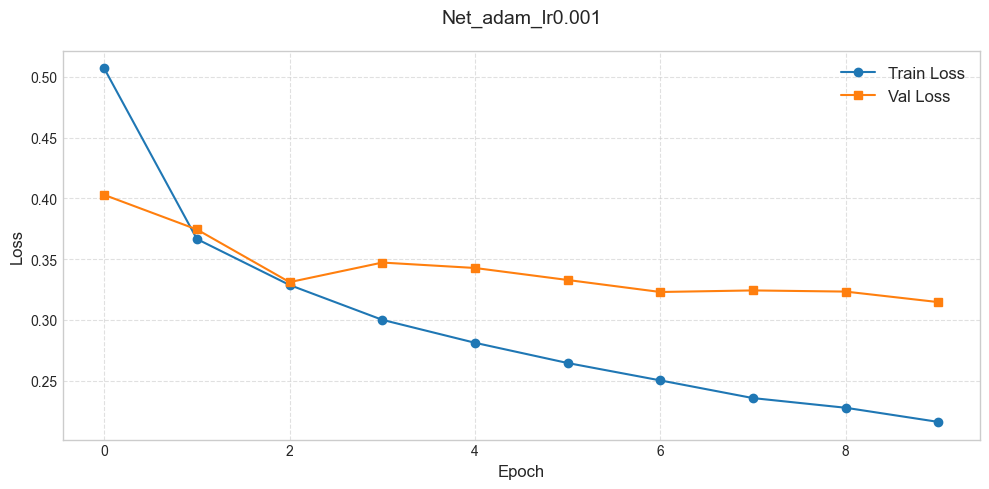

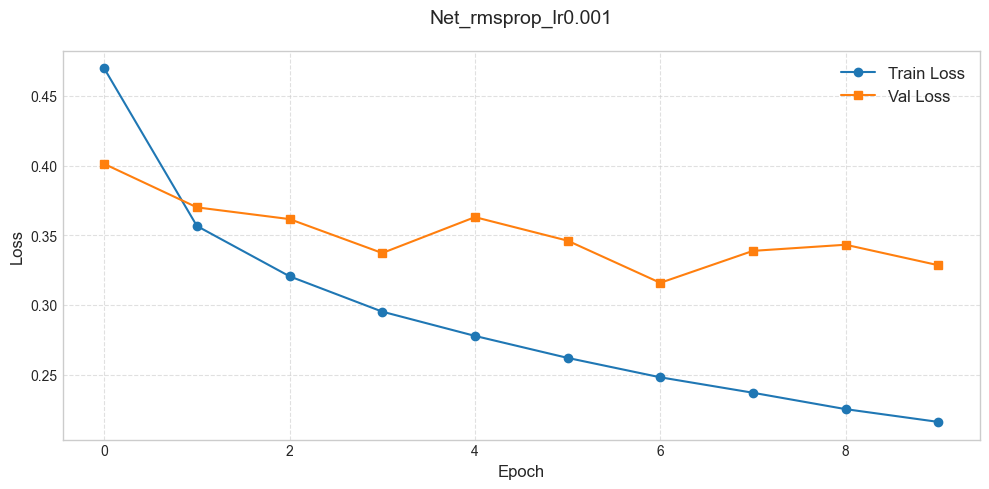

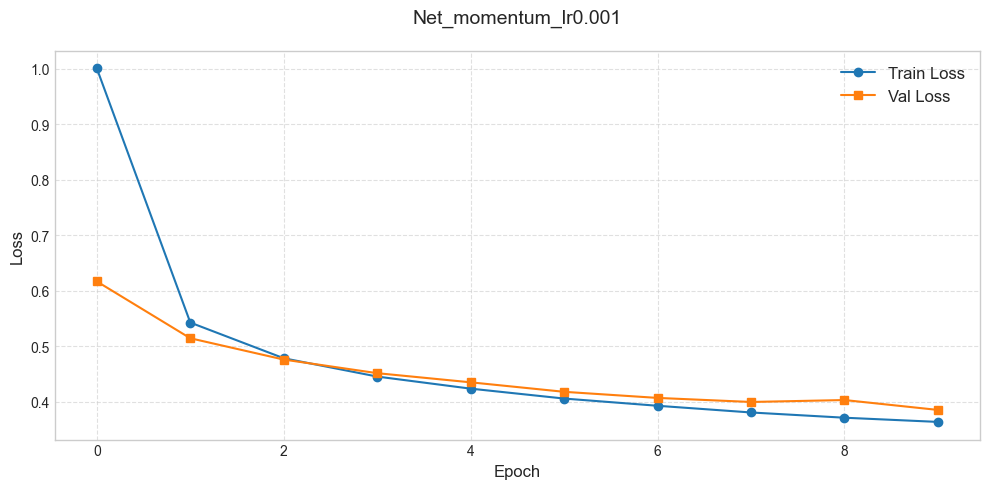

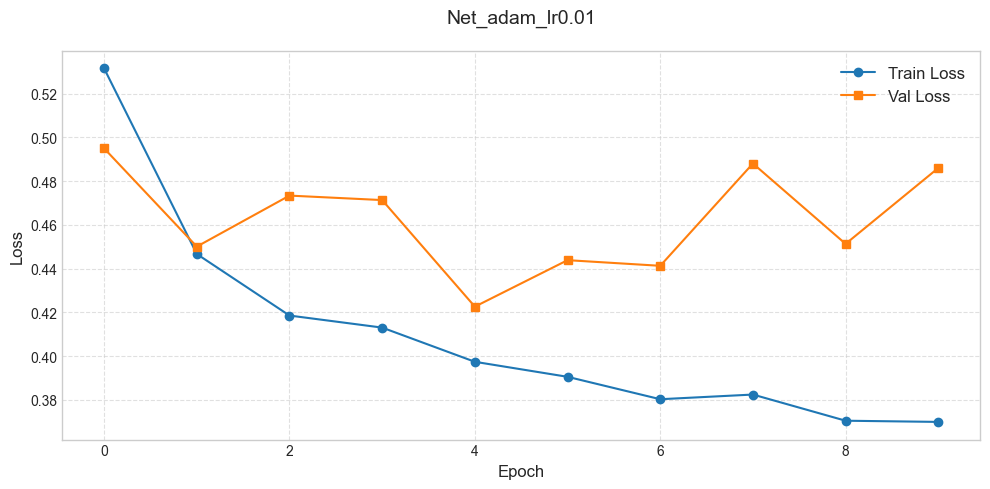

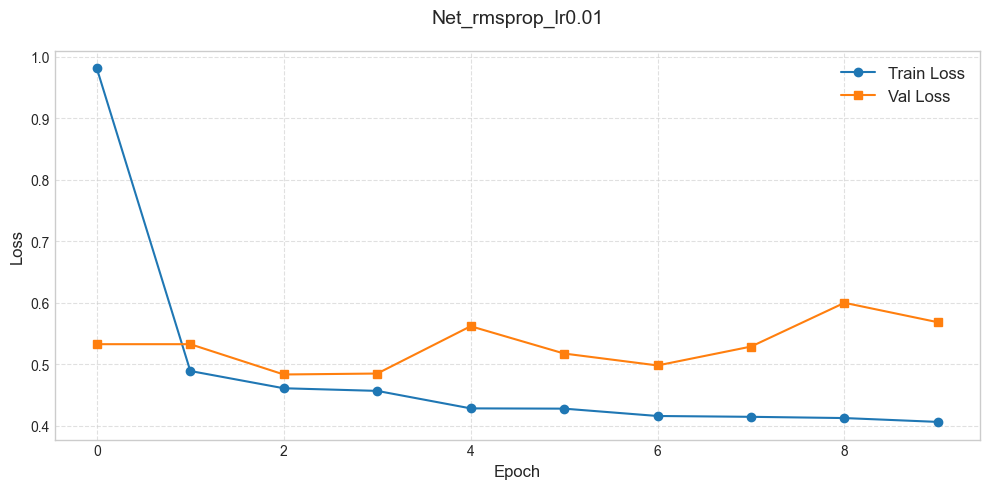

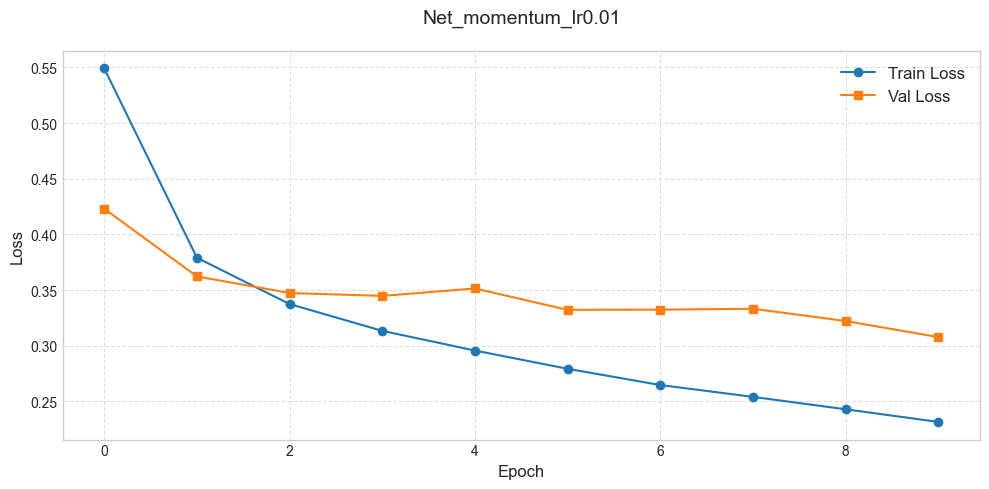

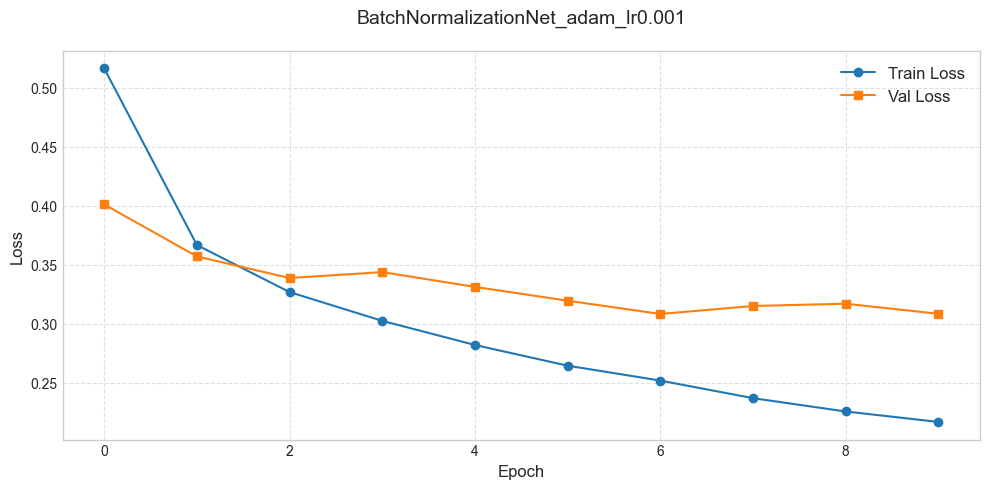

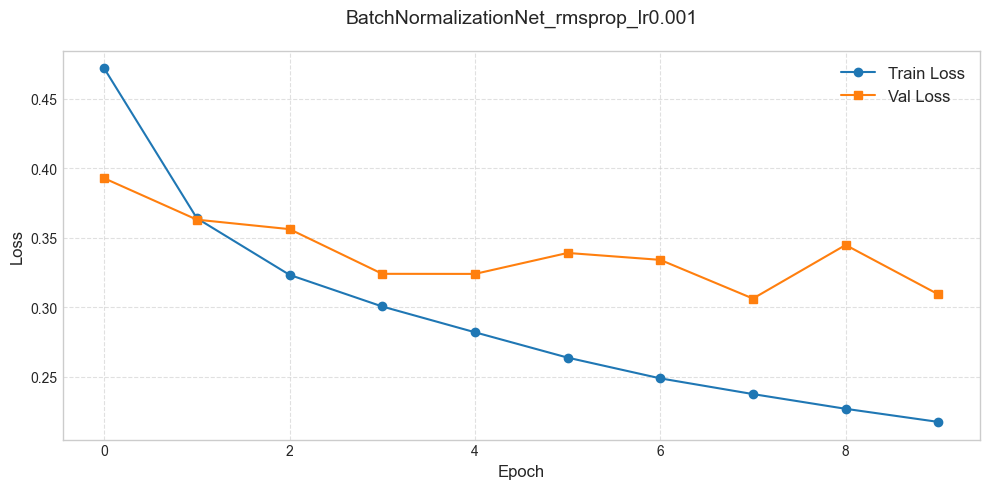

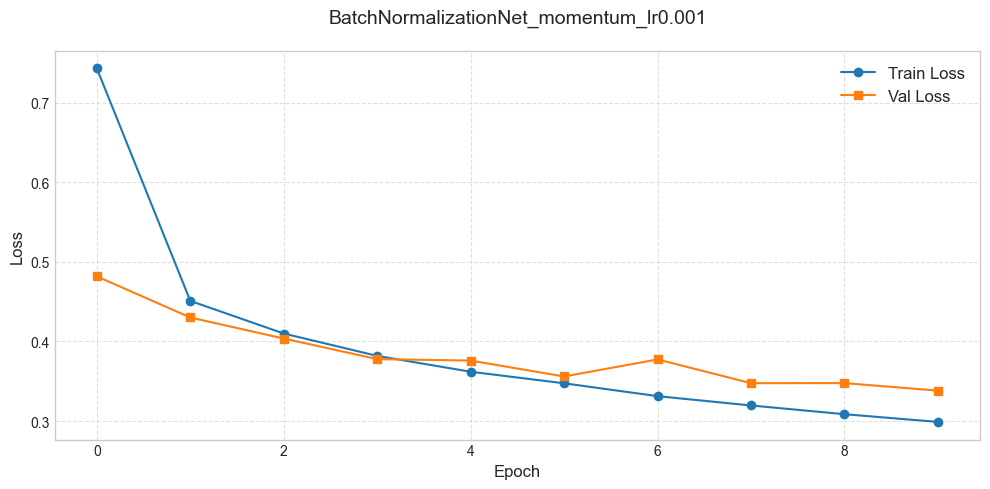

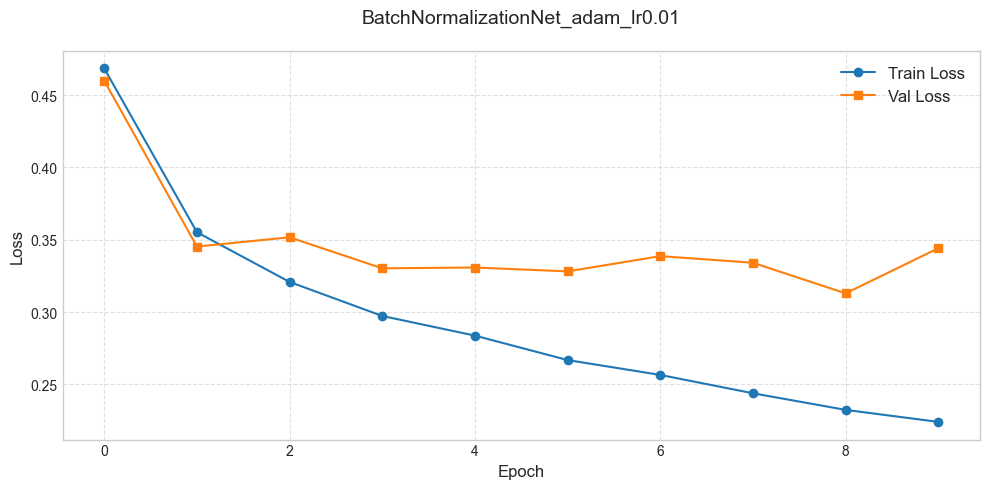

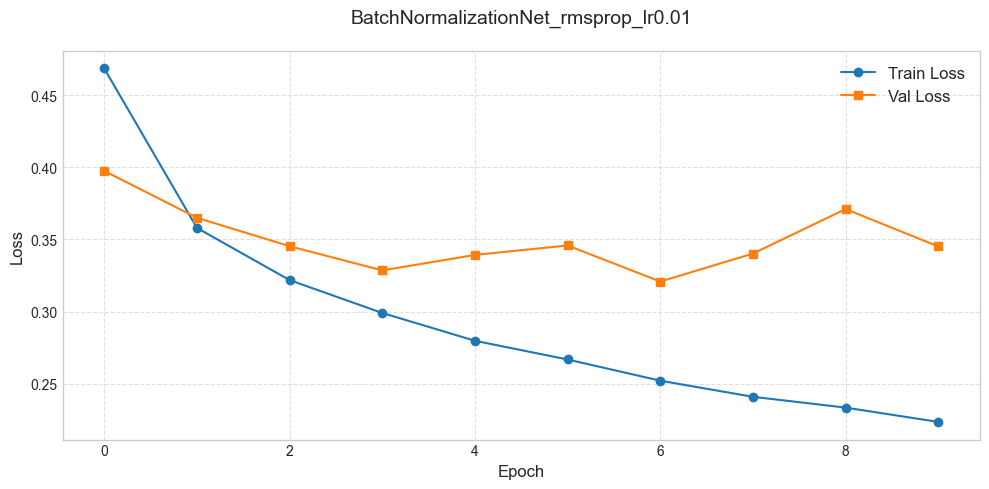

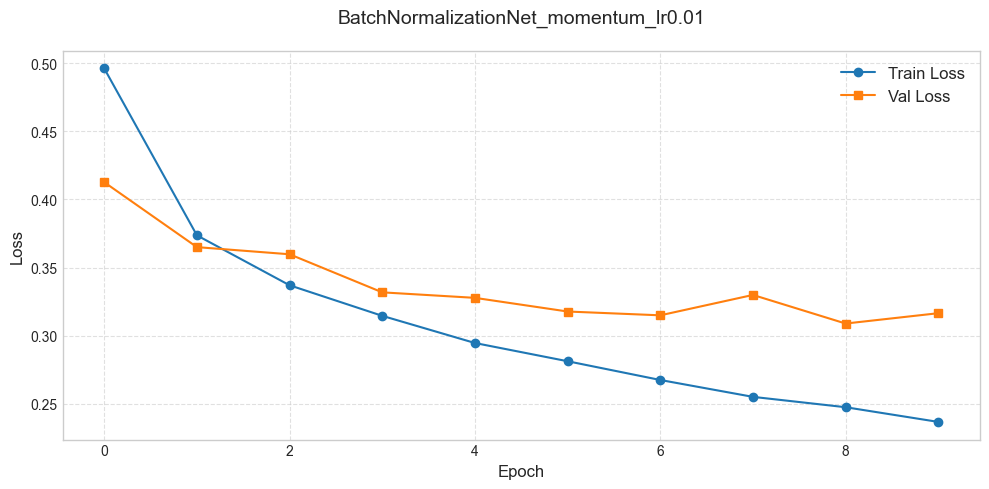

In [107]:
from itertools import product
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

class ExperimentRunner:
    def __init__(self, device='cuda'):
        self.device = device
        self.results = []
        self.figures = []
        
    def _setup_model(self, model_class, lr, optimizer_name):
        model = model_class().to(self.device)
        criterion = nn.CrossEntropyLoss()
        optimizer = self._get_optimizer(optimizer_name, model.parameters(), lr)
        return model, criterion, optimizer
    
    def _get_optimizer(self, name, params, lr):
        optimizers = {
            'adam': lambda p, l: AdamOpt(p, lr=l),
            'rmsprop': optim.RMSprop,
            'momentum': lambda p, l: optim.SGD(p, lr=l, momentum=0.9)
        }
        return optimizers[name](params, lr)
    
    def _create_plot(self, train_loss, val_loss, title):
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(train_loss, label='Train Loss', marker='o')
        ax.plot(val_loss, label='Val Loss', marker='s')
        ax.set_title(title, fontsize=14, pad=20)
        ax.set_xlabel('Epoch', fontsize=12)
        ax.set_ylabel('Loss', fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend(fontsize=12)
        fig.tight_layout()
        self.figures.append((fig, title))
        plt.close(fig)
    
    def run_experiments(self, train_loader, val_loader, num_epochs=10):
        configs = {
            'models': [Net, BatchNormalizationNet],
            'lrs': [0.001, 0.01],
            'optimizers': ['adam', 'rmsprop', 'momentum']
        }
        
        for model_cls, lr, opt_name in product(configs['models'], 
                                             configs['lrs'], 
                                             configs['optimizers']):
            config_str = f"{model_cls.__name__}_{opt_name}_lr{lr}"
            print(f"\n Running experiment: {config_str}")
            
            model, criterion, optimizer = self._setup_model(model_cls, lr, opt_name)
            trainer = ModelTrainer(model, train_loader, val_loader, 
                                 criterion, optimizer, self.device)
            
            train_loss, val_loss = trainer.run(num_epochs, check_gradients=False)
            self._create_plot(train_loss, val_loss, config_str)
            
            self.results.append({
                'Model': model_cls.__name__,
                'Optimizer': opt_name,
                'LR': lr,
                'Final Train Loss': f"{train_loss[-1]:.4f}",
                'Final Val Loss': f"{val_loss[-1]:.4f}",
                'Best Val Loss': f"{min(val_loss):.4f}",
                'Epochs': num_epochs
            })
        
        return pd.DataFrame(self.results)
    
    def show_results(self):
        df = pd.DataFrame(self.results)
        display(df.style
               .background_gradient(subset=['Final Val Loss', 'Best Val Loss'], cmap='RdYlGn_r')
               .set_caption("Summary of All Experiments"))
        
        print("\n Training Curves for All Experiments:")
        for fig, title in self.figures:
            display(fig)
            plt.show()

runner = ExperimentRunner(device=torch.device("cuda" if torch.cuda.is_available() else "cpu"))
results_df = runner.run_experiments(train_loader, val_loader, num_epochs=10)
runner.show_results()

In [121]:
class BestModelTrainer:
    def __init__(self, results_df, device='cuda'):
        self.results_df = results_df
        self.device = device
        self.best_result = None
        self.best_model = None
        self.optimizer = None
        self.train_loss = None
        self.val_loss = None
        
    def analyze_results(self):
        self.best_result = self.results_df.loc[
            self.results_df['Best Val Loss'].astype(float).idxmin()
        ]
        
        print("\n" + "="*60)
        print(f"Лучшая модель:")
        print(f"├── Модель: {self.best_result['Model']}")
        print(f"├── Оптимизатор: {self.best_result['Optimizer']}")
        print(f"├── Learning rate: {self.best_result['LR']}")
        print(f"└── Лучший val_loss: {self.best_result['Best Val Loss']}")
        print("="*60)
        
    def init_best_model(self):
        model_class = Net if self.best_result['Model'] == 'Net' else BatchNormalizationNet
        self.best_model = model_class().to(self.device)
        
        optimizers = {
            'adam': lambda p, lr: AdamOpt(p, lr=lr),
            'rmsprop': optim.RMSprop,
            'momentum': lambda p, lr: optim.SGD(p, lr=lr, momentum=0.9)
        }
        self.optimizer = optimizers[self.best_result['Optimizer']](
            self.best_model.parameters(), 
            lr=float(self.best_result['LR'])
        )
        
    def retrain(self, train_loader, val_loader, num_epochs=10):
        criterion = nn.CrossEntropyLoss()
        trainer = ModelTrainer(
            self.best_model, 
            train_loader, 
            val_loader, 
            criterion, 
            self.optimizer, 
            self.device
        )
        self.train_loss, self.val_loss = trainer.run(num_epochs=num_epochs, check_gradients=False)
        return self.train_loss, self.val_loss
    
    def plot_training_curves(self):
        if self.train_loss is None or self.val_loss is None:
            raise ValueError("Сначала нужно выполнить переобучение (метод retrain)")
            
        plt.figure(figsize=(10, 5))
        plt.plot(self.train_loss, label='Train Loss', marker='o')
        plt.plot(self.val_loss, label='Val Loss', marker='s')
        plt.title(
            f"Кривые обучения | {self.best_result['Model']} + {self.best_result['Optimizer']}\n"
            f"LR: {self.best_result['LR']} | Best Val Loss: {float(self.best_result['Best Val Loss']):.4f}"
        )
        plt.xlabel('Эпоха', fontsize=12)
        plt.ylabel('Loss', fontsize=12)
        plt.legend(fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

In [122]:
class ModelEvaluator:
    def __init__(self, model, device='cuda'):
        self.model = model
        self.device = device
        
    def evaluate(self, test_loader):
        self.model.eval()
        correct = 0
        total = 0
        
        with torch.no_grad():
            for inputs, labels in tqdm(test_loader, desc="Тестирование"):
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                outputs = self.model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        accuracy = 100 * correct / total
        print("\n" + "="*60)
        print(f" Результаты на тестовых данных:")
        print(f"├── Точность: {accuracy:.2f}%")
        print(f"└── Правильно: {correct}/{total}")
        print("="*60)
        return accuracy


Лучшая модель:
├── Модель: BatchNormalizationNet
├── Оптимизатор: rmsprop
├── Learning rate: 0.001
└── Лучший val_loss: 0.3061


Epoch 1/10 - Train Loss: 0.4725, Val Loss: 0.3861


Epoch 2/10 - Train Loss: 0.3612, Val Loss: 0.3569


Epoch 3/10 - Train Loss: 0.3248, Val Loss: 0.3317


Epoch 4/10 - Train Loss: 0.2992, Val Loss: 0.3227


...

Epoch 6/10 - Train Loss: 0.2626, Val Loss: 0.3148


Epoch 7/10 - Train Loss: 0.2491, Val Loss: 0.3095


Epoch 8/10 - Train Loss: 0.2382, Val Loss: 0.3253


Epoch 9/10 - Train Loss: 0.2255, Val Loss: 0.3135


Epoch 10/10 - Train Loss: 0.2184, Val Loss: 0.3158


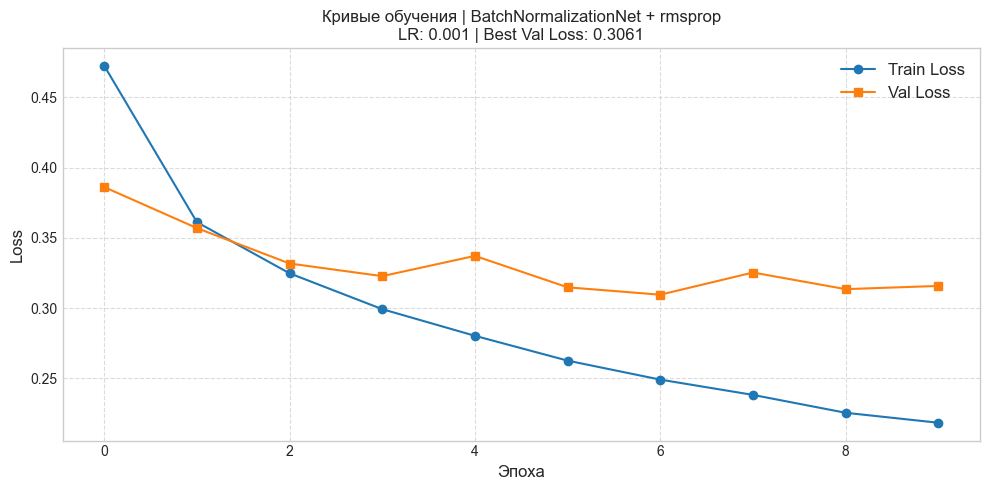

Тестирование: 100%|██████████| 157/157 [00:02<00:00, 73.76it/s] 


 Результаты на тестовых данных:
├── Точность: 88.66%
└── Правильно: 8866/10000


In [123]:
best_trainer = BestModelTrainer(results_df, device)
best_trainer.analyze_results()
best_trainer.init_best_model()
train_loss, val_loss = best_trainer.retrain(train_loader, val_loader)

best_trainer.plot_training_curves()

evaluator = ModelEvaluator(best_trainer.best_model, device)
test_accuracy = evaluator.evaluate(test_loader)